# 3. Metin Ön İşleme
Bu notebook, NLP modelleri için ekstra özellik çıkarımı ve metin temizleme adımlarını içerir.

In [1]:
import pandas as pd
import numpy as np
import re
import string
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import nltk
from textblob import TextBlob
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

tqdm.pandas()

print("Veri yükleniyor...")
df = pd.read_csv('data/reviews_cleaned.csv')
print(f"Veri yüklendi, satır sayısı: {len(df)}")


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\TAHA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\TAHA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\TAHA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\TAHA\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Veri yükleniyor...
Veri yüklendi, satır sayısı: 1629279


## 3.1 Ek Feature Üretimi

In [2]:
print("Feature'lar çıkarılıyor...")
df['text'] = df['text'].astype(str)

df['review_length'] = df['text'].str.len()
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df['exclamation_count'] = df['text'].str.count('!')
df['question_count'] = df['text'].str.count('\\?')

def avg_word_len(text):
    words = text.split()
    if len(words) == 0: return 0
    return sum(len(word) for word in words) / len(words)

df['avg_word_length'] = df['text'].progress_apply(avg_word_len)

def upper_ratio(text):
    if len(text) == 0: return 0
    uppers = sum(1 for c in text if c.isupper())
    return uppers / len(text)

df['uppercase_ratio'] = df['text'].progress_apply(upper_ratio)

def get_sentiment(text):
    blob = TextBlob(text)
    return pd.Series([blob.sentiment.polarity, blob.sentiment.subjectivity])

print("TextBlob sentiment hesaplanıyor...")
df[['sentiment_polarity', 'sentiment_subjectivity']] = df['text'].progress_apply(get_sentiment)

print("\nSınıflara göre feature ortalamaları:")
features = ['review_length', 'word_count', 'exclamation_count', 'question_count', 
            'avg_word_length', 'uppercase_ratio', 'sentiment_polarity', 'sentiment_subjectivity']
print(df.groupby('label')[features].mean())


Feature'lar çıkarılıyor...


  0%|          | 0/1629279 [00:00<?, ?it/s]

  0%|          | 0/1629279 [00:00<?, ?it/s]

TextBlob sentiment hesaplanıyor...


  0%|          | 0/1629279 [00:00<?, ?it/s]


Sınıflara göre feature ortalamaları:
       review_length  word_count  exclamation_count  question_count  \
label                                                                 
0         655.496760  122.424307           0.861445        0.338649   
1         659.260368  122.232242           0.580343        0.211638   
2         491.781597   89.815151           1.562447        0.099228   

       avg_word_length  uppercase_ratio  sentiment_polarity  \
label                                                         
0             4.386876         0.026681           -0.007156   
1             4.406830         0.025142            0.185000   
2             4.540822         0.029878            0.350859   

       sentiment_subjectivity  
label                          
0                    0.530404  
1                    0.548443  
2                    0.592009  


## 3.2 Metin Temizleme Fonksiyonu

In [3]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # 1. Küçük harfe çevir
    text = text.lower()
    
    # 2. HTML tag ve URL temizle
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # 3. Emoji ve unicode kaldır
    text = text.encode('ascii', 'ignore').decode('ascii')
    
    # 4. Noktalama ve özel karakter kaldır
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # 5. Sayıları kaldır
    text = re.sub(r'\d+', '', text)
    
    # 6. Fazla boşlukları temizle
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 7. Tokenize et
    tokens = word_tokenize(text)
    
    # 8-9-10. Stopword kaldır, Lemmatization, 2 karakterden kısa olanları at
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) >= 2]
    
    # 11. Birleştir ve döndür
    return " ".join(cleaned_tokens)


## 3.3 Önce/Sonra Karşılaştırması

In [4]:
sample_reviews = df['text'].sample(5, random_state=42).tolist()
cleaned_samples = [clean_text(text) for text in sample_reviews]

comparison_df = pd.DataFrame({
    'Orijinal Metin': sample_reviews,
    'Temizlenmiş Metin': cleaned_samples
})

pd.set_option('display.max_colwidth', None)
display(comparison_df)


,Orijinal Metin,Temizlenmiş Metin
0,"I wanted to like this place because I love the concept. The workers are super friendly and welcoming. I ordered the Mango smoothie and it was delicious! I then ordered a fish taco, which was decent. I could taste the slaw, lime and mango. It was a nice mixture of flavors to compliment the flaky fish. I then ordered the Santa Fe burrito with chicken and it was bland, mushy and overall not good. I even added the Cholula Hot Sauce, but that didn't help either. My burrito was also a bit burnt by the grill, which added to my disappointment. I will try another smoothie, but will more than likely not eat there again.",wanted like place love concept worker super friendly welcoming ordered mango smoothie delicious ordered fish taco decent could taste slaw lime mango nice mixture flavor compliment flaky fish ordered santa fe burrito chicken bland mushy overall good even added cholula hot sauce help either burrito also bit burnt grill added disappointment try another smoothie likely eat
1,"As far as Steak N Shake's go, this is not the best... The floors are filthy (I could see my footprints behind me as I walked) and slippery. The food was fresh at some point, but not when it came to us. It took a long time for us to even be seated\n\nGiven all of that, the serving staff were all very nice. They were attentive with drinks and were very friendly and positive.\n\nMy bad experience may have been due to the time of day (12am), so I'm willing to give it another shot at either mid-day or 3am...",far steak shake go best floor filthy could see footprint behind walked slippery food fresh point came u took long time u even seated given serving staff nice attentive drink friendly positive bad experience may due time day willing give another shot either mid day
2,terrible sushi...i don't know how people can give it anything higher than 2 star...way overpriced...i paid $95 for 3 people all you can eat...they charged us an extra $20 for not finishing the rice. All you can eat is supposed to be $20.95/person...UNACCEPTABLE!\n\nTry Kokopelli @ Circus Circus instead...much better quality...,terrible sushi know people give anything higher star way overpriced paid people eat charged u extra finishing rice eat supposed person unacceptable try kokopelli circus circus instead much better quality
3,"It's a well established fact that McThrill is hooked on indie coffeehouses (who knew?). And since I had already frequented Benn'as on a couple occasions, I've been interested in trying it's squared counterpart. So since Meredith's BBQ extravaganza brought me to the area anyway, I decided to give it a try along the way.\n\nOver aside from their being much more space nside, I couldn't see much that was different from Benna's, same artsy staff, same strong coffee, same variety of delectable treats, same price. which is normally good and worthy of the same review grade. However with Black n Brew not too far away, and hooking all of that up plus brunch and breakfast burrito I'm kind of inclined to lean toward them (and not just because I need to stop in and see if my friend Carly still works there!).\n\nBut B2 was a grand place to sit and read a book in. And apparently I managed to miss out on things like veggie sandwiches and vegan soft serve ice cream. So it looks like I'm set for round two!",well established fact mcthrill hooked indie coffeehouse knew since already frequented benn couple occasion interested trying squared counterpart since meredith bbq extravaganza brought area anyway decided give try along way aside much space nside see much different benna artsy staff strong coffee variety delectable treat price normally good worthy review grade however black brew far away hooking plus brunch breakfast burrito kind inclined lean toward need stop see friend carly still work grand place sit read book apparently managed miss thing like veggie sandwich vegan soft serve ice cream look like set round two
4,The food was absolutely amaz

## 3.4 Tüm Veriye Uygulama

In [5]:
print("Tüm metinler temizleniyor...")
df['cleaned_text'] = df['text'].progress_apply(clean_text)

initial_len = len(df)
df = df[df['cleaned_text'].str.strip() != '']
df = df.dropna(subset=['cleaned_text'])

dropped = initial_len - len(df)
print(f"\nBoş kaldığı için atılan satır sayısı: {dropped}")
print(f"Kalan veri boyutu: {len(df)}")


Tüm metinler temizleniyor...


  0%|          | 0/1629279 [00:00<?, ?it/s]


Boş kaldığı için atılan satır sayısı: 75
Kalan veri boyutu: 1629204


## 3.5 Feature İstatistikleri

Feature istatistikleri (Mean ve Std):


review_length          word_count          exclamation_count         \
               mean      std       mean      std              mean    std   
label                                                                       
0           655.519  583.333    122.429  109.111             0.861  2.880   
1           659.286  554.526    122.238  102.484             0.580  1.422   
2           491.799  456.358     89.819   83.659             1.563  2.389   

      question_count        avg_word_length        uppercase_ratio         \
                mean    std            mean    std            mean    std   
label                                                                       
0              0.339  1.021           4.384  0.466           0.027  0.019   
1              0.212  0.717           4.404  0.552           0.025  0.013   
2              0.099  0.478           4.538  0.556           0.030  0.018   

      sentiment_polarity        sentiment_subjectivity         
                    mean    std                   mean    std  
label                                                          
0                 -0.007  0.210                  0.530  0.145  
1                  0.185  0.163                  0.548  0.113  
2                  0.351  0.187                  0.592  0.126

C:\Users\TAHA\AppData\Local\Temp\ipykernel_5148\1400781117.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y='sentiment_polarity', palette='Set2')


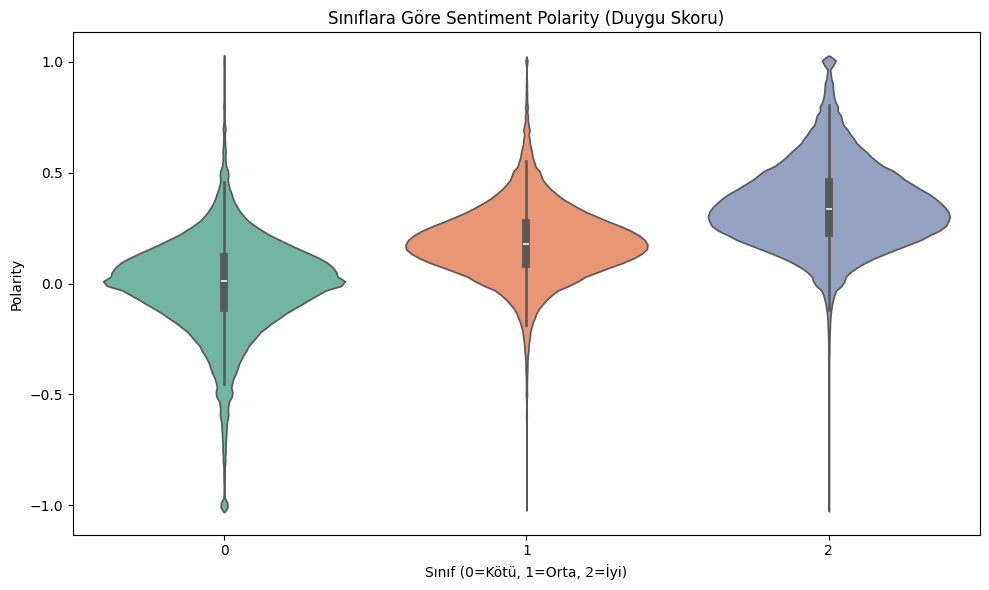

In [6]:
print("Feature istatistikleri (Mean ve Std):")
stats = df.groupby('label')[features].agg(['mean', 'std']).round(3)
display(stats)

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='label', y='sentiment_polarity', palette='Set2')
plt.title('Sınıflara Göre Sentiment Polarity (Duygu Skoru)')
plt.xlabel('Sınıf (0=Kötü, 1=Orta, 2=İyi)')
plt.ylabel('Polarity')
plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/preprocessing_features.png')
plt.show()


## 3.6 Kaydet

In [7]:
output_csv = 'data/reviews_preprocessed.csv'
df.to_csv(output_csv, index=False)

os.makedirs('models', exist_ok=True)
joblib.dump(clean_text, 'models/preprocessor.pkl')

print(f"\n[OK] Kaydedildi: {output_csv}")
print("[OK] Kaydedildi: models/preprocessor.pkl")

display(df.head())



[OK] Kaydedildi: data/reviews_preprocessed.csv
[OK] Kaydedildi: models/preprocessor.pkl


,review_id,business_id,stars,text,useful,funny,cool,date,label,review_length,word_count,exclamation_count,question_count,avg_word_length,uppercase_ratio,sentiment_polarity,sentiment_subjectivity,cleaned_text
0,r_96Iy9M3u4TPMdUMBhK1A,lNkxXDcNoHBpWDNPoZesYw,5,"I enjoyed dining at Caruso's, there was even free caviar during the meal. You should dress up if you are eating here and try to get an ocean view seat. The staff was attentive and made good recommendations. The gnocchi was my favorite dish of the night.",2,2,3,2019-06-15 14:25:55,2,255,47,0,0,4.404255,0.019608,0.500000,0.800000,enjoyed dining caruso even free caviar meal dress eating try get ocean view seat staff attentive made good recommendation gnocchi favorite dish night
1,7bFjWZrdVqjMeHBQI0FHtw,TbIm5iOl6G0gXfDpPDeYTg,1,"What a let down. I used to be a regular here, and now I'll never come back. The food has become a disaster. The meatloaf tastes like it is leftover. The meat on the club sandwich is slimy and sour. Honestly I was afariad to take another bite. That's just some of it. To wait 45 min for old cold food is not my idea of a good diner. \nAlso the staff used to be top notch. The girls at night were fantastic and now the crew in there is rude and they really don't seem like they care to be there. This place has really gone down hill in the last few months.",0,0,0,2015-11-28 06:30:21,0,553,114,0,0,3.850877,0.023508,0.071181,0.376335,let used regular never come back food become disaster meatloaf taste like leftover meat club sandwich slimy sour honestly afariad take another bite wait min old cold food idea good diner also staff used top notch girl night fantastic crew rude really seem like care place really gone hill last month
2,XYyIULnCCIyBkZw6zJNcKg,sCNdu_Anatq1BKuXD86A8A,4,"Kind of a Tourist Trap, but worth it with its great view of the Mississippi and live music and did not have to wait to get seated on our weekday afternoon visit! We dined on 1/2 dozen char grilled oysters a Crab and Shimp Combo with potatoes and corn; and a Fried Seafood Combo platter. Everything served was beyond our expectations and the service was attentive but not intrusive which is how we like it..",1,0,0,2017-05-27 04:19:11,2,408,75,1,0,4.426667,0.029412,0.454091,0.630000,kind tourist trap worth great view mississippi live music wait get seated weekday afternoon visit dined dozen char grilled oyster crab shimp combo potato corn fried seafood combo platter everything served beyond expectation service attentive intrusive like
3,ak5vsDGv7oq8IK00Ze829Q,0RuvlgTnKFbX3IK0ZOOocA,4,It was jammed pack but I can say that I now know why! Brunch was really good! We were a pretty decent size group so I managed to taste different dishes. The pancakes top the charts. So good! Would def come back for a visit again next time I'm in Philly.,0,0,0,2014-11-04 12:56:34,2,253,51,3,0,3.980392,0.043478,0.282407,0.507407,jammed pack say know brunch really good pretty decent size group managed taste different dish pancake top chart good would def come back visit next time philly
4,Xg9Arb4PBeXGdakTzvwTQQ,CYSPKiVdoPX3erovujnE9Q,3,"Harp & Crown was a good place for a group brunch with friends. The buffet has a ton of options. Nothing was wow but overall good. I enjoyed the seafood options, shrimp cocktail and smoked salmon. They have a donut bar where you can add toppings. The donuts themselves were underwhelming. Hot food was also plentiful. The fried chicken bites were good. The best may have been the biscuit with a cheddar gravy. There's an omelette bar. Cocktails. And more.",0,0,0,2019-08-03 14:49:11,1,454,80,0,0,4.687500,0.028634,0.385000,0.610000,harp crown good place group brunch friend buffet ton option nothing wow overall good enjoyed seafood option shrimp cocktail smoked salmon donut bar add topping donut underwhelming hot food also plentiful fried chicken bite good best may biscuit cheddar gravy omelette bar cocktail
